### Introduction ###


### Mathematical Model ###


### Results ###

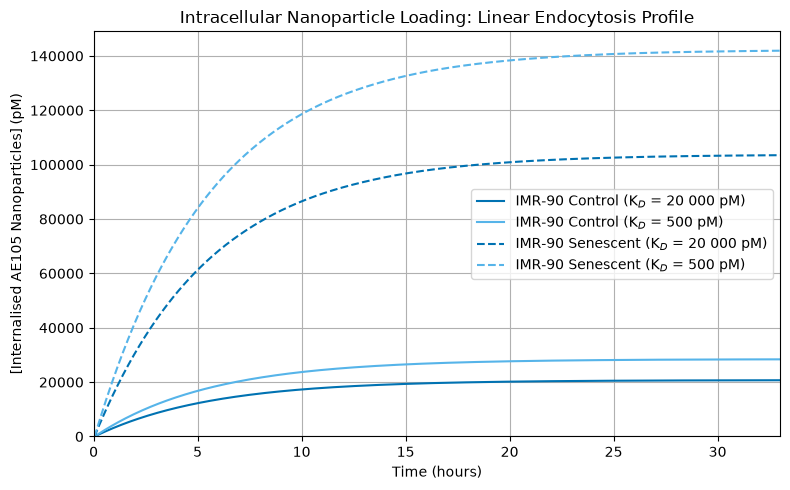

In [40]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from src.plotting import plot_comp
from src.binding import run_binding_model
from src.endocytosis import run_endocytosis_model
from src.constants import *

B_HEAL1 = run_binding_model(R_HEAL, KOFF1, 120000)
B_SEN1 = run_binding_model(R_SEN, KOFF1, 120000)
B_HEAL2 = run_binding_model(R_HEAL, KOFF2, 120000)
B_SEN2 = run_binding_model(R_SEN, KOFF2, 120000)

endo_heal1 = run_endocytosis_model(B_HEAL1, KHALF1)
endo_heal2 = run_endocytosis_model(B_HEAL2, KHALF1)
endo_sen1 = run_endocytosis_model(B_SEN1, KHALF1)
endo_sen2 = run_endocytosis_model(B_SEN2, KHALF1)

plot_comp("Intracellular Nanoparticle Loading: Linear Endocytosis Profile", "Time (hours)", "[Internalised AE105 Nanoparticles] (pM)", 33, 
        (endo_heal1.t/3600, endo_heal1.y[0], r"IMR-90 Control (K$_D$ = 20 000 pM)"),
        (endo_heal2.t/3600, endo_heal2.y[0], r"IMR-90 Control (K$_D$ = 500 pM)"),
        (endo_sen1.t/3600, endo_sen1.y[0], r"IMR-90 Senescent (K$_D$ = 20 000 pM)"),
        (endo_sen2.t/3600, endo_sen2.y[0], r"IMR-90 Senescent (K$_D$ = 500 pM)"))

Figure 3.1. Intracellular AE105 nanoparticle accumulation over time modeled via a constant, non-saturable first-order uPAR internalization rate k<sub>int</sub> in IMR-90 fibroblasts.

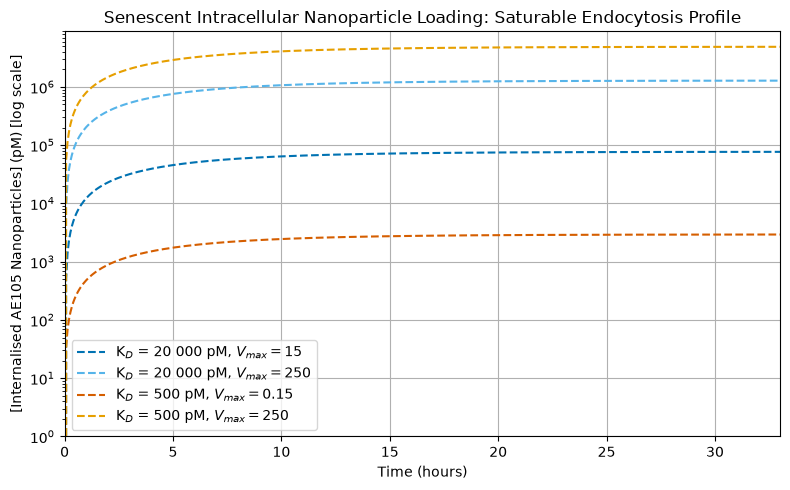

In [41]:
B_SEN1 = run_binding_model(R_SEN, KOFF1, 120000)
B_SEN2 = run_binding_model(R_SEN, KOFF2, 120000)

I_SEN1 = run_endocytosis_model(B_SEN1, KHALF1, VMAX1, 2) 
I_SEN2 = run_endocytosis_model(B_SEN1, KHALF1, VMAXc ,2)
I_SEN3 = run_endocytosis_model(B_SEN2, KHALF2, VMAX2, 2)
I_SEN4 = run_endocytosis_model(B_SEN2, KHALF2, VMAXc, 2)

plot_comp("Senescent Intracellular Nanoparticle Loading: Saturable Endocytosis Profile", "Time (hours)", "[Internalised AE105 Nanoparticles] (pM) [log scale]", 33, 
        (I_SEN1.t/3600, I_SEN1.y[0], r"K$_D$ = 20 000 pM, $V_{max} = 15$"),
        (I_SEN2.t/3600, I_SEN2.y[0], r"K$_D$ = 20 000 pM, $V_{max} = 250$"),
        (I_SEN3.t/3600, I_SEN3.y[0], r"K$_D$ = 500 pM, $V_{max} = 0.15$"),
        (I_SEN4.t/3600, I_SEN4.y[0], r"K$_D$ = 500 pM, $V_{max} = 250$"))



Figure 3.2 Intracellular AE105 nanoparticle accumulation modeled with a saturable Michaelis-Menten extension tracking clathrin-coated pit capacity limits V<sub>max</sub> during uPAR-mediated endocytosis (update is so only for). --(Dashed line overlay: non-saturable profile comparison).--    # not updated, old

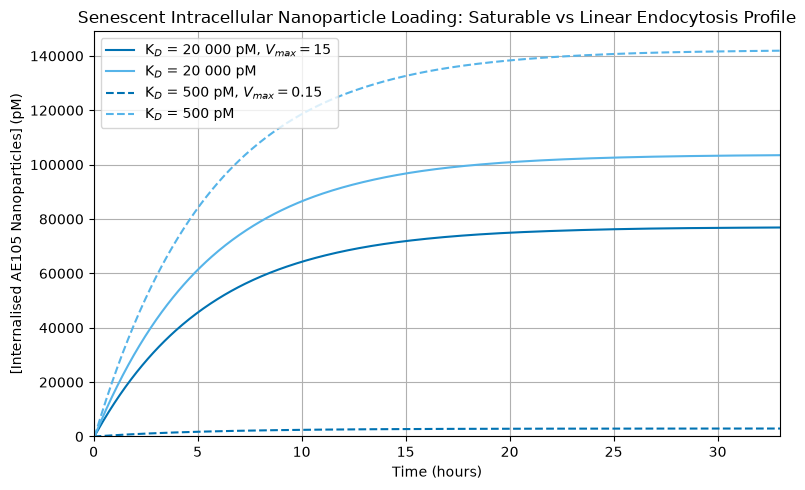

In [42]:
# KD2 for high-avidity multivalent particle model, compare VMAX2 (clathrin pathway speed limit under saturated surface binding) and
# VMAX1 (for conjugated peptide)...
# comparing just effect of conj. vs h.a. - 1v3 (darker colours)
# comparing just effect of change in Vmax - 1v2 and 3v4 (i.e. two blues, two oranges compare ea.)
# note: is there a difference in rate to get to max / the curve itself, apart from just moving up/down etc?? Maybe but hard to see...


plot_comp("Senescent Intracellular Nanoparticle Loading: Saturable vs Linear Endocytosis Profile", "Time (hours)", "[Internalised AE105 Nanoparticles] (pM)", 33, 
        (I_SEN1.t/3600, I_SEN1.y[0], r"K$_D$ = 20 000 pM, $V_{max} = 15$"),
        (endo_sen1.t/3600, endo_sen1.y[0], r"K$_D$ = 20 000 pM"),
        (I_SEN3.t/3600, I_SEN3.y[0], r"K$_D$ = 500 pM, $V_{max} = 0.15$"),
        (endo_sen2.t/3600, endo_sen2.y[0], r"K$_D$ = 500 pM"))



### Interpretation ###

expected - if true etc Senescent cells exhibit greater nanoparticle internalisation because increased receptor density produces more bound complexes available for endocytosis.

### Limitations ###

note - The model assumes a constant endocytosis rate and does not include intracellular degradation, recycling, or exocytosis.

### Discussion ###
